# Breast Cancer Classification Using Machine Learning

## Objective
The objective of this project is to classify breast cancer tumors as benign or malignant using machine learning techniques.

## Dataset
Breast Cancer Wisconsin Dataset from scikit-learn.

## Algorithm Used
Random Forest Classifier

## Accuracy Achieved
96.49%

## Conclusion
The model successfully classified tumors with high accuracy and demonstrated the effectiveness of machine learning in healthcare prediction tasks.

In [43]:
import pandas as pd
import numpy as np
print("Breast Cancer Classification Project Started")

Breast Cancer Classification Project Started


In [44]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [45]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Target Values:")
print(df['target'].head())

print("\nMissing Values:")
print(df.isnull().sum().sum())

Dataset Shape: (569, 31)

First 5 Target Values:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Missing Values:
0


In [46]:
X = df.drop('target', axis=1)
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


In [48]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [49]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 96.49 %


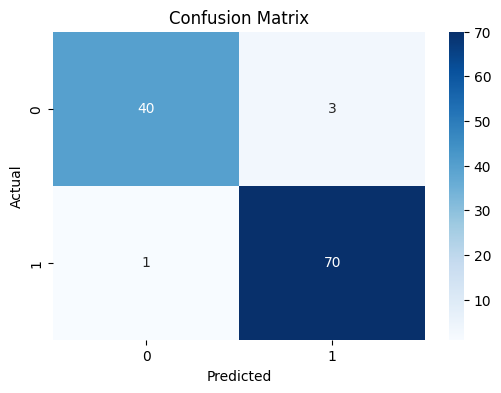

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



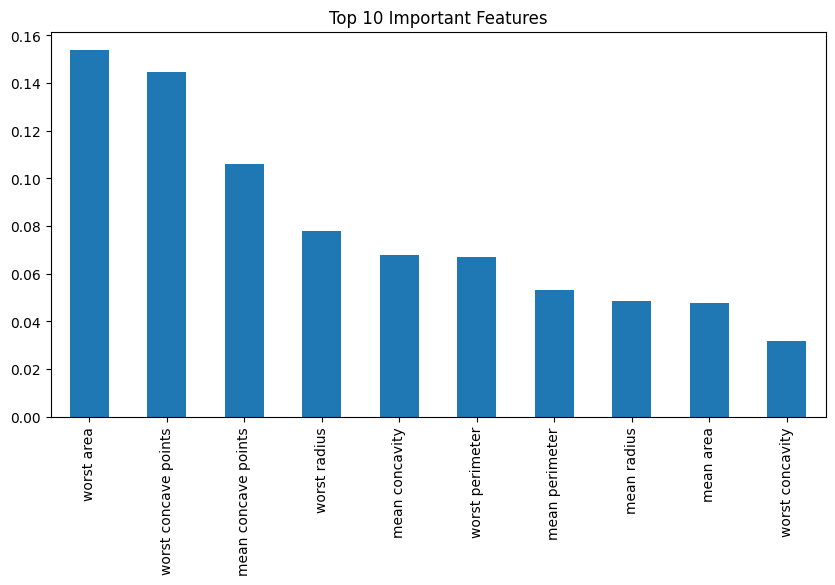

In [52]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()

# Future Improvements

- Try other machine learning algorithms such as SVM and Logistic Regression.
- Perform hyperparameter tuning to improve accuracy.
- Build a web application using Flask or Streamlit for real-time predictions.